In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
plt.style.use('seaborn-v0_8-darkgrid')
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/FINAL_ML/K234131619.csv"
df = pd.read_csv(file_path)

Mounted at /content/drive


## Question 1: Exploratory Data Analysis and Outlier Detection


### a) Perform summary statistics analysis on the key numerical variables (e.g., unit_sales, onpromotion, cluster) and describe their distributions (mean, median, standard deviation, min, max)

In [3]:
df = pd.read_csv(file_path)
df['date'] = pd.to_datetime(df['date'])
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nHead:")
display(df.head())

Shape: (1730, 13)

Columns: ['date', 'store_nbr', 'item_nbr', 'type', 'cluster', 'state', 'family', 'class', 'perishable', 'store_type', 'family_encoded', 'state_encoded', 'unit_sales']

Head:


,date,store_nbr,item_nbr,type,cluster,state,family,class,perishable,store_type,family_encoded,state_encoded,unit_sales
0,2013-01-12,5,103665,D,4,Santo Domingo de los Tsachilas,BREAD/BAKERY,2712,1,3,0,2,7.0
1,2013-01-12,5,105574,D,4,Santo Domingo de los Tsachilas,GROCERY I,1045,0,3,1,2,14.0
2,2013-01-12,5,105575,D,4,Santo Domingo de los Tsachilas,GROCERY I,1045,0,3,1,2,28.0
3,2013-01-12,5,105577,D,4,Santo Domingo de los Tsachilas,GROCERY I,1045,0,3,1,2,8.0
4,2013-01-12,5,105693,D,4,Santo Domingo de los Tsachilas,GROCERY I,1034,0,3,1,2,3.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1730 entries, 0 to 1729
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            1730 non-null   datetime64[ns]
 1   store_nbr       1730 non-null   int64         
 2   item_nbr        1730 non-null   int64         
 3   type            1730 non-null   object        
 4   cluster         1730 non-null   int64         
 5   state           1730 non-null   object        
 6   family          1730 non-null   object        
 7   class           1730 non-null   int64         
 8   perishable      1730 non-null   int64         
 9   store_type      1730 non-null   int64         
 10  family_encoded  1730 non-null   int64         
 11  state_encoded   1730 non-null   int64         
 12  unit_sales      1730 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(8), object(3)
memory usage: 175.8+ KB


In [5]:
df["date"] = pd.to_datetime(df["date"])

print("Missing values by column:")
display(df.isnull().sum())

print("\nDuplicated rows:", df.duplicated().sum())
print("\nDate range:", df["date"].min(), "to", df["date"].max())
print("Number of distinct dates:", df["date"].nunique())
print("\nObservations by date:")
display(df["date"].value_counts().sort_index())

Missing values by column:


,0
date,0
store_nbr,0
item_nbr,0
type,0
cluster,0
state,0
family,0
class,0
perishable,0
store_type,0



Duplicated rows: 0

Date range: 2013-01-12 00:00:00 to 2013-01-12 00:00:00
Number of distinct dates: 1

Observations by date:


,count
date,
2013-01-12,1730


In [6]:
numerical_cols_for_stats = ["store_nbr","item_nbr","store_type","family_encoded","state_encoded", "unit_sales", "cluster", "class", "perishable"]

desc_stats = (
    df[numerical_cols_for_stats]
    .agg(["mean", "median", "std", "min", "max"])
    .T
    .round(4)
)

display(desc_stats)


,mean,median,std,min,max
store_nbr,9.5780,5.0,5.4237,5.000,16.000
item_nbr,615847.4775,586940.0,303076.5195,103501.000,1114749.000
store_type,2.5838,3.0,0.4931,2.000,3.000
family_encoded,3.2468,2.0,3.4258,0.000,19.000
state_encoded,2.0000,2.0,0.0000,2.000,2.000
unit_sales,6.6276,4.0,8.2955,0.192,100.535
cluster,3.5838,4.0,0.4931,3.000,4.000
class,1924.1954,1124.0,1117.5488,1002.000,7034.000
perishable,0.2023,0.0,0.4018,0.000,1.000


### b) Visualizations and Pattern Discovery

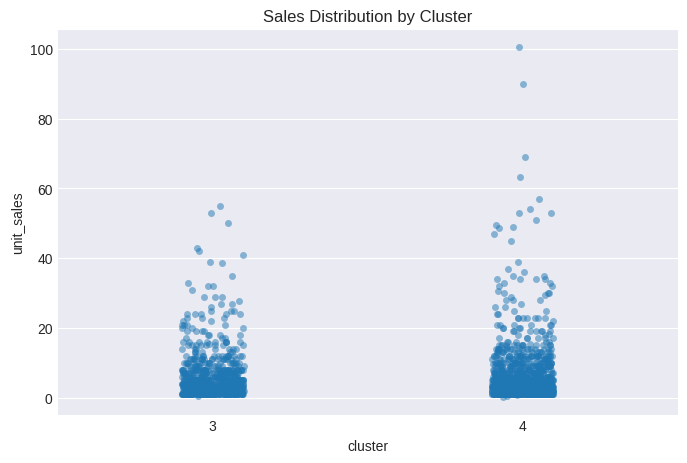

In [7]:
plt.figure(figsize=(8,5))
sns.stripplot(data=df, x="cluster", y="unit_sales", jitter=True, alpha=0.5)

plt.title("Sales Distribution by Cluster")
plt.savefig("sales_by_cluster.png", dpi=300, bbox_inches='tight')
plt.show()

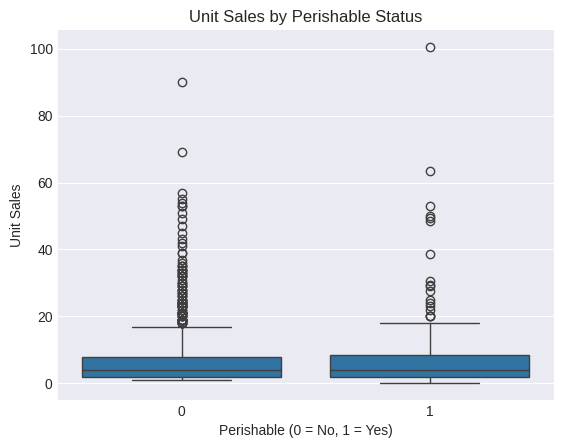

In [8]:
sns.boxplot(x='perishable', y='unit_sales', data=df)

plt.title("Unit Sales by Perishable Status")
plt.xlabel("Perishable (0 = No, 1 = Yes)")
plt.ylabel("Unit Sales")
plt.savefig("sales_by_perishable.png", dpi=300, bbox_inches='tight')
plt.show()

In [9]:
!pip install plotly
import pandas as pd
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots
pio.renderers.default = 'colab'

In [10]:
df_C = (
    df.query("type == 'C'")
      .groupby("family")["unit_sales"]
      .sum()
      .reset_index()
      .sort_values("unit_sales", ascending=False)
)
df_D = (
    df.query("type == 'D'")
      .groupby("family")["unit_sales"]
      .sum()
      .reset_index()
      .sort_values("unit_sales", ascending=False)
)

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("Store C", "Store D")
)
color = "#636EFA"
fig.add_trace(
    go.Bar(
        x=df_C["family"],
        y=df_C["unit_sales"],
        text=df_C["unit_sales"],
        textposition='outside',
        marker_color=color
    ),
    row=1, col=1
)
fig.add_trace(
    go.Bar(
        x=df_D["family"],
        y=df_D["unit_sales"],
        text=df_D["unit_sales"],
        textposition='outside',
        marker_color=color
    ),
    row=2, col=1
)
fig.update_layout(
    height=900,
    width=1100,
    title="Total Sales by Family - Store C vs D",
    showlegend=False
)
fig.update_xaxes(tickangle=-45)
fig.show()

### c) Outlier Detection and Impact Analysis

Q1: 2.0
Q3: 8.0
IQR: 6.0
Lower bound: -7.0
Upper bound: 17.0
Number of outliers: 120
Percentage of outliers: 6.94 %


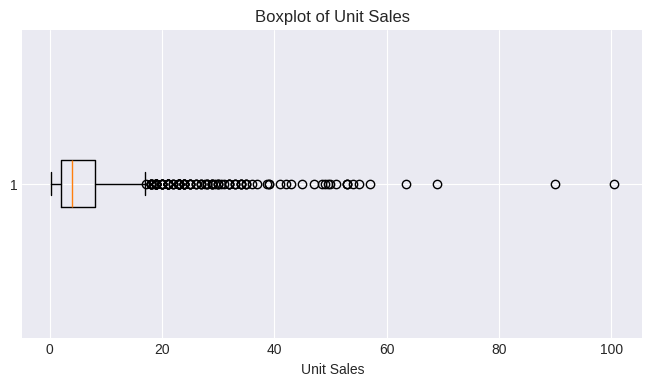

In [11]:
Q1 = df["unit_sales"].quantile(0.25)
Q3 = df["unit_sales"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df["unit_sales"] < lower_bound) | (df["unit_sales"] > upper_bound)]
num_outliers = outliers.shape[0]
total = len(df)
pct_outliers = (num_outliers / total) * 100

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
print("Number of outliers:", num_outliers)
print("Percentage of outliers:", round(pct_outliers, 2), "%")

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.boxplot(df["unit_sales"], vert=False)
plt.title("Boxplot of Unit Sales")
plt.xlabel("Unit Sales")
plt.show()

## Question 2

### a) Construct at least four meaningful features derived from the original variables (e.g., lag features, rolling statistics, promotion indicators)

In [12]:
# Create working copy
df_features = df.copy()

# feature 1:
df_features['store_family'] = (
    df_features['store_nbr'].astype(str) + "_" + df_features['family'].astype(str)
)
# feature 2:
df_features['store_class'] = (
    df_features['store_nbr'].astype(str) + "_" + df_features['class'].astype(str)
)

# feature 3:
df_features['family_perishable'] = (
    df_features['family'].astype(str) + "_" + df_features['perishable'].astype(str)
)

# feature 4:
class_freq_map = df_features['class'].value_counts()
df_features['class_freq'] = df_features['class'].map(class_freq_map)

# feature 5:
family_freq_map = df_features['family'].value_counts()
df_features['family_freq'] = df_features['family'].map(family_freq_map)

# feature 6:
family_item_count = df_features.groupby('family')['item_nbr'].nunique().reset_index()
family_item_count.columns = ['family', 'product_complexity']
df_features = df_features.merge(family_item_count, on='family', how='left')

# Define new features list
new_features = [
    'store_family', 'store_class',
    'family_perishable',
    'class_freq', 'family_freq',
    'product_complexity'
]

print(" ALL 6 FEATURES CREATED SUCCESSFULLY")
print(f"\nFeatures created: {len(new_features)}")
print(f"Rows preserved: {df.shape[0]} → {df_features.shape[0]} ✓")
print(f"Total columns: {df_features.shape[1]}\n")

# Display sample rows
print("Sample of first 5 rows with engineered features:")
print("-"*80)
sample_cols = [
    'date', 'store_nbr', 'item_nbr', 'family', 'class', 'perishable', 'unit_sales',
    'store_family', 'store_class',
    'family_perishable', 'class_freq', 'family_freq', 'product_complexity'
]
print(df_features[sample_cols].head().to_string(index=False))
print(df_features[sample_cols].tail(10).to_string(index=False))

 ALL 6 FEATURES CREATED SUCCESSFULLY

Features created: 6
Rows preserved: 1730 → 1730 ✓
Total columns: 19

Sample of first 5 rows with engineered features:
--------------------------------------------------------------------------------
      date  store_nbr  item_nbr       family  class  perishable  unit_sales   store_family store_class family_perishable  class_freq  family_freq  product_complexity
2013-01-12          5    103665 BREAD/BAKERY   2712           1         7.0 5_BREAD/BAKERY      5_2712    BREAD/BAKERY_1           8           69                  55
2013-01-12          5    105574    GROCERY I   1045           0        14.0    5_GROCERY I      5_1045       GROCERY I_0          25          752                 506
2013-01-12          5    105575    GROCERY I   1045           0        28.0    5_GROCERY I      5_1045       GROCERY I_0          25          752                 506
2013-01-12          5    105577    GROCERY I   1045           0         8.0    5_GROCERY I      5_1

### c) Explain how feature engineering can affect model bias and variance in sales forecasting

In [13]:
import pandas as pd
from IPython.display import display

print("CHECKING ENGINEERED FEATURES")

# dùng df_features vì đây là dataframe đã tạo feature
target_df = df_features.copy()

eng_features = [
    'store_family',
    'store_class',
    'family_perishable',
    'class_freq',
    'family_freq',
    'product_complexity'
]

eng_features_to_check = [f for f in eng_features if f in target_df.columns]

if not eng_features_to_check:
    print("[WARN] No engineered features found.")
else:
    rows = []

    for feat in eng_features_to_check:
        if pd.api.types.is_numeric_dtype(target_df[feat]):
            rows.append({
                "Feature": feat,
                "Type": "Numerical",
                "Min": target_df[feat].min(),
                "Max": target_df[feat].max(),
                "Mean": target_df[feat].mean(),
                "Variance": target_df[feat].var(),
                "Std_Dev": target_df[feat].std(),
                "Unique": target_df[feat].nunique(),
                "Missing": target_df[feat].isna().sum()
            })
        else:
            rows.append({
                "Feature": feat,
                "Type": "Categorical",
                "Min": "-",
                "Max": "-",
                "Mean": "-",
                "Variance": "-",
                "Std_Dev": "-",
                "Unique": target_df[feat].nunique(),
                "Missing": target_df[feat].isna().sum()
            })

    feature_stats_df = pd.DataFrame(rows)
    display(feature_stats_df)

CHECKING ENGINEERED FEATURES


,Feature,Type,Min,Max,Mean,Variance,Std_Dev,Unique,Missing
0,store_family,Categorical,-,-,-,-,-,38,0
1,store_class,Categorical,-,-,-,-,-,266,0
2,family_perishable,Categorical,-,-,-,-,-,20,0
3,class_freq,Numerical,1,64,25.818497,280.153272,16.73778,41,0
4,family_freq,Numerical,1,752,422.127168,92527.980349,304.184122,19,0
5,product_complexity,Numerical,1,506,287.518497,41019.798674,202.533451,19,0


## Question 3: Variable Selection and Encoding Strategy

### a) Variable Identification and Analysis

In [14]:
# Numerical variable
print(f"""
1. NUMERIC VARIABLE: unit_sales (Numerical)
   • Type: Continuous numerical variable
   • Range: [{target_df['unit_sales'].min()}, {target_df['unit_sales'].max()}]
   • Mean: {target_df['unit_sales'].mean():.2f}
   • Skewness: {target_df['unit_sales'].skew():.3f}
   • Rationale:
     - Represents the quantity sold per (store, item)
     - right-skewed → large sales act as outliers
""")

# Numerical variable
print(f"""
2. NUMERICAL VARIABLE: class_freq
   • Type: Discrete numerical (count-based)
   • Range: [{target_df['class_freq'].min()}, {target_df['class_freq'].max()}]
   • Mean: {target_df['class_freq'].mean():.2f}
   • Rationale:
     - Measures the frequency of each product class in the dataset
     - Proxy for category prevalence or market presence
     - Helps capture differences in demand between common and less common product classes
""")

# Categorical variable
print(f"""
3. CATEGORICAL VARIABLE: family
   • Type: Nominal categorical variable
   • Unique Categories: {target_df['family'].nunique()}
   • Sample Categories: {list(target_df['family'].unique())[:10]}
   • Rationale:
     - Represents product grouping
     - No inherent ordering → purely categorical
     - Different families have different demand patterns
""")


1. NUMERIC VARIABLE: unit_sales (Numerical)
   • Type: Continuous numerical variable
   • Range: [0.192, 100.535]
   • Mean: 6.63
   • Skewness: 3.993
   • Rationale:
     - Represents the quantity sold per (store, item)
     - right-skewed → large sales act as outliers


2. NUMERICAL VARIABLE: class_freq
   • Type: Discrete numerical (count-based)
   • Range: [1, 64]
   • Mean: 25.82
   • Rationale:
     - Measures the frequency of each product class in the dataset
     - Proxy for category prevalence or market presence
     - Helps capture differences in demand between common and less common product classes


3. CATEGORICAL VARIABLE: family
   • Type: Nominal categorical variable
   • Unique Categories: 20
   • Sample Categories: ['BREAD/BAKERY', 'GROCERY I', 'DELI', 'CLEANING', 'POULTRY', 'PERSONAL CARE', 'LINGERIE', 'BEVERAGES', 'AUTOMOTIVE', 'DAIRY']
   • Rationale:
     - Represents product grouping
     - No inherent ordering → purely categorical
     - Different families have 

### b) Explain how each variable type should be encoded for use in regression models (one-hot encoding, label encoding, ordinal encoding).

In [15]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

print('Applying One-Hot Encoding...')

# List of categorical features to one-hot encode

categorical_features_to_encode = ['store_family', 'store_class', 'family_perishable']


# Apply one-hot encoding using pd.get_dummies

df_features_encoded = pd.get_dummies(df_features, columns=categorical_features_to_encode, drop_first=False)


print(f"Original number of columns: {df_features.shape[1]}")

print(f"New number of columns after encoding: {df_features_encoded.shape[1]}")


# Update df_features to the encoded version

df_features = df_features_encoded.copy()


print('\nOne-Hot Encoding complete. Displaying head of the updated DataFrame:')

display(df_features.head())

Applying One-Hot Encoding...
Original number of columns: 19
New number of columns after encoding: 340

One-Hot Encoding complete. Displaying head of the updated DataFrame:


,date,store_nbr,item_nbr,type,cluster,state,family,class,perishable,store_type,...,family_perishable_GROCERY I_0,family_perishable_HARDWARE_0,family_perishable_LAWN AND GARDEN_0,family_perishable_LINGERIE_0,"family_perishable_LIQUOR,WINE,BEER_0",family_perishable_MEATS_1,family_perishable_PERSONAL CARE_0,family_perishable_POULTRY_1,family_perishable_PREPARED FOODS_1,family_perishable_SEAFOOD_1
0,2013-01-12,5,103665,D,4,Santo Domingo de los Tsachilas,BREAD/BAKERY,2712,1,3,...,False,False,False,False,False,False,False,False,False,False
1,2013-01-12,5,105574,D,4,Santo Domingo de los Tsachilas,GROCERY I,1045,0,3,...,True,False,False,False,False,False,False,False,False,False
2,2013-01-12,5,105575,D,4,Santo Domingo de los Tsachilas,GROCERY I,1045,0,3,...,True,False,False,False,False,False,False,False,False,False
3,2013-01-12,5,105577,D,4,Santo Domingo de los Tsachilas,GROCERY I,1045,0,3,...,True,False,False,False,False,False,False,False,False,False
4,2013-01-12,5,105693,D,4,Santo Domingo de los Tsachilas,GROCERY I,1034,0,3,...,True,False,False,False,False,False,False,False,False,False


In [16]:
from sklearn.preprocessing import StandardScaler

print('Applying StandardScaler to class_freq, family_freq, product_complexity and creating new columns...')

columns_to_scale = ['class_freq', 'family_freq', 'product_complexity', 'unit_sales']

scaler = StandardScaler()

for col in columns_to_scale:

    df_features[f'{col}_scaled'] = scaler.fit_transform(df_features[[col]])

print('\nStandardization complete. Displaying head of the updated DataFrame with new scaled columns:')

display(df_features.head())

Applying StandardScaler to class_freq, family_freq, product_complexity and creating new columns...

Standardization complete. Displaying head of the updated DataFrame with new scaled columns:


,date,store_nbr,item_nbr,type,cluster,state,family,class,perishable,store_type,...,"family_perishable_LIQUOR,WINE,BEER_0",family_perishable_MEATS_1,family_perishable_PERSONAL CARE_0,family_perishable_POULTRY_1,family_perishable_PREPARED FOODS_1,family_perishable_SEAFOOD_1,class_freq_scaled,family_freq_scaled,product_complexity_scaled,unit_sales_scaled
0,2013-01-12,5,103665,D,4,Santo Domingo de los Tsachilas,BREAD/BAKERY,2712,1,3,...,False,False,False,False,False,False,-1.064875,-1.161235,-1.148382,0.044908
1,2013-01-12,5,105574,D,4,Santo Domingo de los Tsachilas,GROCERY I,1045,0,3,...,False,False,False,False,False,False,-0.048915,1.084765,1.079055,0.888988
2,2013-01-12,5,105575,D,4,Santo Domingo de los Tsachilas,GROCERY I,1045,0,3,...,False,False,False,False,False,False,-0.048915,1.084765,1.079055,2.577148
3,2013-01-12,5,105577,D,4,Santo Domingo de los Tsachilas,GROCERY I,1045,0,3,...,False,False,False,False,False,False,-0.048915,1.084765,1.079055,0.165491
4,2013-01-12,5,105693,D,4,Santo Domingo de los Tsachilas,GROCERY I,1034,0,3,...,False,False,False,False,False,False,1.265857,1.084765,1.079055,-0.437423


In [17]:
output_path = '/content/processed_data.csv'

df_features.to_csv(output_path, index=False)

print(f"Processed data saved to {output_path}")

Processed data saved to /content/processed_data.csv


##Question 4


### a) Build and train a Support Vector Regression (SVR) model for sales prediction using Python. Experiment with different hyperparameter values (C, epsilon) and report the model performance

In [18]:
!pip uninstall -y rmm cudf cuml
!pip install cudf-cu12==24.4.1 cuml-cu12==24.4.1 rmm-cu12==24.4.1 --extra-index-url https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [19]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import KFold, cross_validate
import time

# Ensure unit_sales_log1p is created (if not already present)
if 'unit_sales_log1p' not in df_features.columns:
    df_features['unit_sales_log1p'] = np.log1p(df_features['unit_sales'])

# 1. Chuẩn bị dữ liệu
cols_to_drop = [
    'date', 'store_nbr', 'item_nbr', 'type', 'state', 'family', 'class',
    'perishable', 'unit_sales', 'unit_sales_scaled',
    'state_family', 'state_class', 'family_perishable', # Original engineered categorical features
    'class_freq', 'family_freq', 'product_complexity', 'unit_sales_log1p'
]

# Filter columns from df_features that are numeric and not in cols_to_drop
X_processed = df_features.drop(columns=[col for col in cols_to_drop if col in df_features.columns], errors='ignore')
y = df_features["unit_sales_log1p"]

print("SVR MODEL DEVELOPMENT WITH K-FOLD (K=5) - Using unit_sales_log1p as target")
print("-" * 50)

# 2. Cấu hình K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Thử nghiệm Hyperparameters
C_values = [0.1, 1.0, 10.0, 100]
epsilon_values = [0.01, 0.1, 0.5] # Updated epsilon values

results_svr = []

for C in C_values:
    for eps in epsilon_values:
        start_time = time.time()

        svr = SVR(C=C, epsilon=eps, kernel='rbf')

        # Perform Cross Validation
        # Use the log-transformed y for training and evaluation
        cv_results = cross_validate(svr, X_processed, y, cv=kf,
                                    scoring={
                                        'neg_rmse_log': 'neg_root_mean_squared_error',
                                        'neg_rmse_train_log': 'neg_root_mean_squared_error', # For train RMSE
                                        'neg_mae_log': 'neg_mean_absolute_error', # For MAE
                                        'r2_log': 'r2'
                                    },
                                    return_estimator=False, # No need to return estimators for this task
                                    return_train_score=True) # Ensure train scores are returned

        avg_rmse_log = -cv_results['test_neg_rmse_log'].mean() # RMSE on log scale (test)
        avg_rmse_train_log = -cv_results['train_neg_rmse_log'].mean() # RMSE on log scale (train)
        avg_mae_log = -cv_results['test_neg_mae_log'].mean() # MAE on log scale (test)
        avg_r2_log = cv_results['test_r2_log'].mean() # R2 on log scale (test)

        overfit_gap = avg_rmse_log - avg_rmse_train_log # Calculate Overfit_Gap

        duration = time.time() - start_time

        results_svr.append({
            'C': C,
            'Epsilon': eps,
            'Avg_RMSE_LogScale': avg_rmse_log,
            'Avg_MAE_LogScale': avg_mae_log, # New metric
            'Avg_R2_LogScale': avg_r2_log,
            'Overfit_Gap_RMSE': overfit_gap, # New metric
            'Total_Time': duration
        })
        print(f"Done: C={C}, eps={eps} | Avg RMSE (Log): {avg_rmse_log:.4f} | Avg MAE (Log): {avg_mae_log:.4f} | Avg R2 (Log): {avg_r2_log:.4f} | Overfit Gap: {overfit_gap:.4f}")

# 4. Hiển thị kết quả tổng hợp
svr_results_df_features = pd.DataFrame(results_svr)
print("\nSVR K-FOLD COMPARISON TABLE (using unit_sales_log1p as target)")
display(svr_results_df_features.sort_values(by='Avg_RMSE_LogScale'))

SVR MODEL DEVELOPMENT WITH K-FOLD (K=5) - Using unit_sales_log1p as target
--------------------------------------------------
Done: C=0.1, eps=0.01 | Avg RMSE (Log): 0.7670 | Avg MAE (Log): 0.6194 | Avg R2 (Log): -0.0052 | Overfit Gap: 0.0092
Done: C=0.1, eps=0.1 | Avg RMSE (Log): 0.7685 | Avg MAE (Log): 0.6212 | Avg R2 (Log): -0.0090 | Overfit Gap: 0.0106
Done: C=0.1, eps=0.5 | Avg RMSE (Log): 0.7644 | Avg MAE (Log): 0.6184 | Avg R2 (Log): 0.0016 | Overfit Gap: 0.0070
Done: C=1.0, eps=0.01 | Avg RMSE (Log): 0.7559 | Avg MAE (Log): 0.6113 | Avg R2 (Log): 0.0241 | Overfit Gap: 0.0380
Done: C=1.0, eps=0.1 | Avg RMSE (Log): 0.7547 | Avg MAE (Log): 0.6121 | Avg R2 (Log): 0.0269 | Overfit Gap: 0.0372
Done: C=1.0, eps=0.5 | Avg RMSE (Log): 0.7502 | Avg MAE (Log): 0.6084 | Avg R2 (Log): 0.0387 | Overfit Gap: 0.0313
Done: C=10.0, eps=0.01 | Avg RMSE (Log): 0.7742 | Avg MAE (Log): 0.6191 | Avg R2 (Log): -0.0250 | Overfit Gap: 0.0989
Done: C=10.0, eps=0.1 | Avg RMSE (Log): 0.7669 | Avg MAE (Log)

,C,Epsilon,Avg_RMSE_LogScale,Avg_MAE_LogScale,Avg_R2_LogScale,Overfit_Gap_RMSE,Total_Time
5,1.0,0.50,0.750178,0.608415,0.038680,0.031331,3.462480
8,10.0,0.50,0.752434,0.605807,0.032479,0.080461,3.487924
4,1.0,0.10,0.754677,0.612104,0.026941,0.037167,7.735775
3,1.0,0.01,0.755865,0.611307,0.024108,0.038046,6.204798
11,100.0,0.50,0.759794,0.611609,0.013232,0.095088,3.627306
2,0.1,0.50,0.764406,0.618412,0.001619,0.006993,4.029742
7,10.0,0.10,0.766919,0.616194,-0.005632,0.096293,7.540954
0,0.1,0.01,0.767002,0.619413,-0.005207,0.009160,15.073412
1,0.1,0.10,0.768477,0.621167,-0.009022,0.010560,12.175564
6,10.0,0.01,0.774213,0.619052,-0.024962,0.098938,6.585544


In [20]:
# Best model based on RMSE (lower is better)
best_rmse_model = svr_results_df_features.loc[svr_results_df_features['Avg_RMSE_LogScale'].idxmin()]
print("\n--- Best SVR Model by Avg_RMSE_LogScale ---")
print(f"Best hyperparameters: C={best_rmse_model['C']}, Epsilon={best_rmse_model['Epsilon']}")
print(f"Avg RMSE (Log Scale): {best_rmse_model['Avg_RMSE_LogScale']:.4f}")
print(f"Avg MAE (Log Scale): {best_rmse_model['Avg_MAE_LogScale']:.4f}")
print(f"Avg R2 (Log Scale): {best_rmse_model['Avg_R2_LogScale']:.4f}")
print(f"Overfit Gap RMSE: {best_rmse_model['Overfit_Gap_RMSE']:.4f}")

# Best model based on MAE (lower is better)
best_mae_model = svr_results_df_features.loc[svr_results_df_features['Avg_MAE_LogScale'].idxmin()]
print("\n--- Best SVR Model by Avg_MAE_LogScale ---")
print(f"Best hyperparameters: C={best_mae_model['C']}, Epsilon={best_mae_model['Epsilon']}")
print(f"Avg RMSE (Log Scale): {best_mae_model['Avg_RMSE_LogScale']:.4f}")
print(f"Avg MAE (Log Scale): {best_mae_model['Avg_MAE_LogScale']:.4f}")
print(f"Avg R2 (Log Scale): {best_mae_model['Avg_R2_LogScale']:.4f}")
print(f"Overfit Gap RMSE: {best_mae_model['Overfit_Gap_RMSE']:.4f}")

# Best model based on R2 (higher is better)
best_r2_model = svr_results_df_features.loc[svr_results_df_features['Avg_R2_LogScale'].idxmax()]
print("\n--- Best SVR Model by Avg_R2_LogScale ---")
print(f"Best hyperparameters: C={best_r2_model['C']}, Epsilon={best_r2_model['Epsilon']}")
print(f"Avg RMSE (Log Scale): {best_r2_model['Avg_RMSE_LogScale']:.4f}")
print(f"Avg MAE (Log Scale): {best_r2_model['Avg_MAE_LogScale']:.4f}")
print(f"Avg R2 (Log Scale): {best_r2_model['Avg_R2_LogScale']:.4f}")
print(f"Overfit Gap RMSE: {best_r2_model['Overfit_Gap_RMSE']:.4f}")

# Best model based on Overfit Gap (lower is better, indicating less overfitting)
best_overfit_model = svr_results_df_features.loc[svr_results_df_features['Overfit_Gap_RMSE'].idxmin()]
print("\n--- Best SVR Model by Overfit_Gap_RMSE (least overfitting) ---")
print(f"Best hyperparameters: C={best_overfit_model['C']}, Epsilon={best_overfit_model['Epsilon']}")
print(f"Avg RMSE (Log Scale): {best_overfit_model['Avg_RMSE_LogScale']:.4f}")
print(f"Avg MAE (Log Scale): {best_overfit_model['Avg_MAE_LogScale']:.4f}")
print(f"Avg R2 (Log Scale): {best_overfit_model['Avg_R2_LogScale']:.4f}")
print(f"Overfit Gap RMSE: {best_overfit_model['Overfit_Gap_RMSE']:.4f}")


--- Best SVR Model by Avg_RMSE_LogScale ---
Best hyperparameters: C=1.0, Epsilon=0.5
Avg RMSE (Log Scale): 0.7502
Avg MAE (Log Scale): 0.6084
Avg R2 (Log Scale): 0.0387
Overfit Gap RMSE: 0.0313

--- Best SVR Model by Avg_MAE_LogScale ---
Best hyperparameters: C=10.0, Epsilon=0.5
Avg RMSE (Log Scale): 0.7524
Avg MAE (Log Scale): 0.6058
Avg R2 (Log Scale): 0.0325
Overfit Gap RMSE: 0.0805

--- Best SVR Model by Avg_R2_LogScale ---
Best hyperparameters: C=1.0, Epsilon=0.5
Avg RMSE (Log Scale): 0.7502
Avg MAE (Log Scale): 0.6084
Avg R2 (Log Scale): 0.0387
Overfit Gap RMSE: 0.0313

--- Best SVR Model by Overfit_Gap_RMSE (least overfitting) ---
Best hyperparameters: C=0.1, Epsilon=0.5
Avg RMSE (Log Scale): 0.7644
Avg MAE (Log Scale): 0.6184
Avg R2 (Log Scale): 0.0016
Overfit Gap RMSE: 0.0070


### b) Compare the prediction performance of SVR with different values of C and epsilon. Present your results in a table or visualization

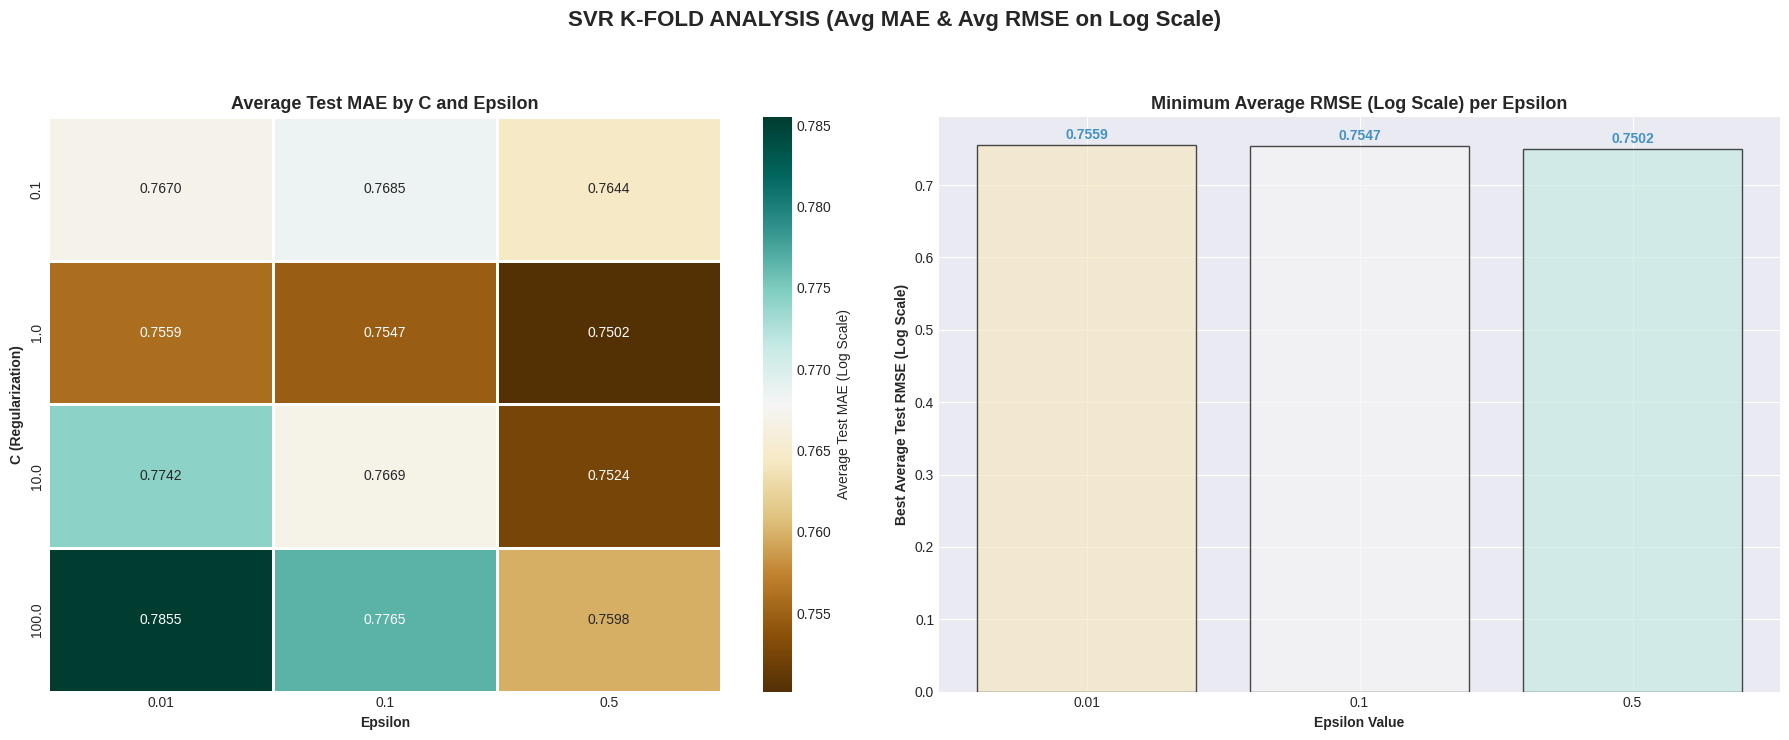


✓ SVR K-Fold analysis plots rendered.


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ============================================================================================
# VISUALIZATION: 2 SUPPLEMENTARY SVR PLOTS (K-Fold Cross-Validation Results)
# ============================================================================================

# 0. Chuẩn bị dữ liệu Pivot và Epsilon từ kết quả K-Fold
pivot_r2_log = svr_results_df_features.pivot(index='C', columns='Epsilon', values='Avg_RMSE_LogScale')
epsilon_best_rmse_log = svr_results_df_features.groupby('Epsilon')['Avg_RMSE_LogScale'].min()

# 1. Khởi tạo Figure 1 hàng 2 cột
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('SVR K-FOLD ANALYSIS (Avg MAE & Avg RMSE on Log Scale)', fontsize=16, fontweight='bold', y=1.05)

# --- HÌNH 1: HEATMAP AVG R² (trên thang đo Logarit) ---
sns.heatmap(pivot_r2_log, annot=True, fmt='.4f', cmap='BrBG', ax=axes[0],
            cbar_kws={'label': 'Average Test MAE (Log Scale)'}, linewidths=1, linecolor='white')
axes[0].set_title('Average Test MAE by C and Epsilon', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epsilon', fontweight='bold')
axes[0].set_ylabel('C (Regularization)', fontweight='bold')

# --- HÌNH 2: BAR CHART EPSILON PERFORMANCE (trên thang đo Logarit) ---
bar_colors = plt.cm.BrBG(np.linspace(0.4, 0.6, len(epsilon_best_rmse_log))) # Dùng tông nhạt hơn

axes[1].bar(range(len(epsilon_best_rmse_log)), epsilon_best_rmse_log.values, color=bar_colors, edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(epsilon_best_rmse_log)))
axes[1].set_xticklabels(epsilon_best_rmse_log.index)
axes[1].set_title('Minimum Average RMSE (Log Scale) per Epsilon', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epsilon Value', fontweight='bold')
axes[1].set_ylabel('Best Average Test RMSE (Log Scale)', fontweight='bold')

# Thêm nhãn con số lên đầu cột
for i, v in enumerate(epsilon_best_rmse_log.values):
    axes[1].text(i, v + (max(epsilon_best_rmse_log.values) * 0.01), f'{v:.4f}',
                 ha='center', fontweight='bold', color='#4292C6')

plt.tight_layout()
plt.show()

print("\n✓ SVR K-Fold analysis plots rendered.")

### c) Compare the advantages and disadvantages of SVM compared to other regression methods in terms of handling non-linear relationships, scalability, and interpretability for sales prediction.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import KFold, cross_validate
import pandas as pd
import numpy as np
import time

def run_cross_validation(model, X, y, kf):
    start_time = time.time()
    cv_results = cross_validate(model, X, y, cv=kf,
                                scoring={
                                    'neg_rmse_log': 'neg_root_mean_squared_error',
                                    'neg_rmse_train_log': 'neg_root_mean_squared_error',
                                    'neg_mae_log': 'neg_mean_absolute_error',
                                    'r2_log': 'r2'
                                },
                                return_train_score=True)

    avg_rmse_log = -cv_results['test_neg_rmse_log'].mean()
    avg_rmse_train_log = -cv_results['train_neg_rmse_log'].mean()
    avg_mae_log = -cv_results['test_neg_mae_log'].mean()
    avg_r2_log = cv_results['test_r2_log'].mean()
    duration = time.time() - start_time
    overfit_gap = avg_rmse_log - avg_rmse_train_log

    return avg_rmse_log, avg_mae_log, avg_r2_log, overfit_gap, duration

print("EMPIRICAL COMPARISON: TRAINING OTHER MODELS WITH K-FOLD CROSS-VALIDATION")
print("=" * 100)

# Initialize results list
comparison_data = []

# Ensure X_processed, y, kf are available from previous cells
# (These variables are in the kernel state)

# 1. Linear Regression
lr_model = LinearRegression()
lr_rmse, lr_mae, lr_r2, lr_overfit_gap, lr_time = run_cross_validation(lr_model, X_processed, y, kf)
comparison_data.append({
    'Model': 'Linear Regression',
    'Test_RMSE_LogScale': lr_rmse,
    'Test_MAE_LogScale': lr_mae,
    'Test_R2_LogScale': lr_r2,
    'Overfit_Gap_RMSE': lr_overfit_gap,
    'Training_Time': lr_time,
    'Interpretability': 'Excellent'
})
print(f"Done: Linear Regression | Avg RMSE (Log): {lr_rmse:.4f} | Avg MAE (Log): {lr_mae:.4f} | Avg R2 (Log): {lr_r2:.4f} | Overfit Gap: {lr_overfit_gap:.4f}")

# 2. Decision Tree
dt_model = DecisionTreeRegressor(random_state=42, max_depth=15, min_samples_split=20)
dt_rmse, dt_mae, dt_r2, dt_overfit_gap, dt_time = run_cross_validation(dt_model, X_processed, y, kf)
comparison_data.append({
    'Model': 'Decision Tree',
    'Test_RMSE_LogScale': dt_rmse,
    'Test_MAE_LogScale': dt_mae,
    'Test_R2_LogScale': dt_r2,
    'Overfit_Gap_RMSE': dt_overfit_gap,
    'Training_Time': dt_time,
    'Interpretability': 'Excellent'
})
print(f"Done: Decision Tree | Avg RMSE (Log): {dt_rmse:.4f} | Avg MAE (Log): {dt_mae:.4f} | Avg R2 (Log): {dt_r2:.4f} | Overfit Gap: {dt_overfit_gap:.4f}")

# 3. Random Forest
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_rmse, rf_mae, rf_r2, rf_overfit_gap, rf_time = run_cross_validation(rf_model, X_processed, y, kf)
comparison_data.append({
    'Model': 'Random Forest',
    'Test_RMSE_LogScale': rf_rmse,
    'Test_MAE_LogScale': rf_mae,
    'Test_R2_LogScale': rf_r2,
    'Overfit_Gap_RMSE': rf_overfit_gap,
    'Training_Time': rf_time,
    'Interpretability': 'Poor'
})
print(f"Done: Random Forest | Avg RMSE (Log): {rf_rmse:.4f} | Avg MAE (Log): {rf_mae:.4f} | Avg R2 (Log): {rf_r2:.4f} | Overfit Gap: {rf_overfit_gap:.4f}")

# Add SVR (Best) results to the comparison data
# Assuming 'best_rmse_model' Series is available from the previous cell's execution
comparison_data.append({
    'Model': 'SVR',
    'Test_RMSE_LogScale': best_rmse_model['Avg_RMSE_LogScale'],
    'Test_MAE_LogScale': best_rmse_model['Avg_MAE_LogScale'],
    'Test_R2_LogScale': best_rmse_model['Avg_R2_LogScale'],
    'Overfit_Gap_RMSE': best_rmse_model['Overfit_Gap_RMSE'],
    'Training_Time': best_rmse_model['Total_Time'],
    'Interpretability': 'Poor'
})


comparison_results = pd.DataFrame(comparison_data)

print("MODEL COMPARISON TABLE (K-Fold Cross-Validation on Log Scale)")

display(comparison_results.sort_values(by='Test_RMSE_LogScale'))

# Tìm và in Best Model theo RMSE
best_model_name_overall = comparison_results.loc[comparison_results['Test_RMSE_LogScale'].idxmin(), 'Model']
print(f"\nOverall Best Model by Test_RMSE_LogScale: {best_model_name_overall}")

EMPIRICAL COMPARISON: TRAINING OTHER MODELS WITH K-FOLD CROSS-VALIDATION
Done: Linear Regression | Avg RMSE (Log): 0.7675 | Avg MAE (Log): 0.6191 | Avg R2 (Log): -0.0079 | Overfit Gap: 0.1248
Done: Decision Tree | Avg RMSE (Log): 0.7633 | Avg MAE (Log): 0.6157 | Avg R2 (Log): 0.0031 | Overfit Gap: 0.0709
Done: Random Forest | Avg RMSE (Log): 0.7633 | Avg MAE (Log): 0.6129 | Avg R2 (Log): 0.0029 | Overfit Gap: 0.1162
MODEL COMPARISON TABLE (K-Fold Cross-Validation on Log Scale)


,Model,Test_RMSE_LogScale,Test_MAE_LogScale,Test_R2_LogScale,Overfit_Gap_RMSE,Training_Time,Interpretability
3,SVR,0.750178,0.608415,0.038680,0.031331,3.462480,Poor
2,Random Forest,0.763316,0.612878,0.002858,0.116220,11.758099,Poor
1,Decision Tree,0.763348,0.615697,0.003122,0.070925,0.864075,Excellent
0,Linear Regression,0.767515,0.619067,-0.007858,0.124811,1.492559,Excellent



Overall Best Model by Test_RMSE_LogScale: SVR


## Question 5

### a) Build and train a decision tree regression model for sales prediction using Python, including the role of key hyperparameters (max_depth, min_samples_split, etc.).

In [23]:
# Decision Tree Hyperparameter Combinations
max_depth_values = [5, 10, 15, 20, 25, 30, None] # Expanded range, including None for no limit
min_samples_split_values = [5, 10, 20, 30, 40] # Expanded range

results_dt = []

print("\nTraining Decision Tree models with different hyperparameters (K-Fold Cross-Validation)...")
print(f"max_depth values to test: {max_depth_values}")
print(f"min_samples_split values to test: {min_samples_split_values}")
print(f"Total combinations: {len(max_depth_values) * len(min_samples_split_values)}")

for depth in max_depth_values:
    for min_split in min_samples_split_values:
        # Create Decision Tree model with current hyperparameters
        dt_model = DecisionTreeRegressor(max_depth=depth, min_samples_split=min_split,
                                         random_state=42)

        # Run K-Fold Cross-Validation using the helper function
        avg_rmse_log, avg_mae_log, avg_r2_log, overfit_gap, duration = run_cross_validation(dt_model, X_processed, y, kf)

        results_dt.append({
            'Max_Depth': depth,
            'Min_Samples_Split': min_split,
            'Avg_RMSE_LogScale': avg_rmse_log,
            'Avg_MAE_LogScale': avg_mae_log,
            'Avg_R2_LogScale': avg_r2_log,
            'Overfit_Gap_RMSE': overfit_gap,
            'Training_Time': duration
        })

        print(f"✓ Depth={str(depth):4s}, MinSplit={min_split:2d} | Avg RMSE (Log): {avg_rmse_log:.4f} | Avg MAE (Log): {avg_mae_log:.4f} | Avg R2 (Log): {avg_r2_log:.4f} | Overfit Gap: {overfit_gap:.4f}")

# Create results dataframe
dt_results_df = pd.DataFrame(results_dt)

print("\n" + "=" * 100)
print("DECISION TREE HYPERPARAMETER COMPARISON TABLE (K-Fold Cross-Validation)")
print("=" * 100)
# Sort by Avg_RMSE_LogScale for easier interpretation
display(dt_results_df.sort_values(by='Avg_RMSE_LogScale'))

# Find best Decision Tree model by Avg_RMSE_LogScale
best_dt_model_info = dt_results_df.loc[dt_results_df['Avg_RMSE_LogScale'].idxmin()]

print(f"\n{'='*100}")
print("BEST DECISION TREE MODEL (by Avg_RMSE_LogScale)")
print(f"{'='*100}")
print(f"Best hyperparameters: max_depth={best_dt_model_info['Max_Depth']}, min_samples_split={best_dt_model_info['Min_Samples_Split']}")
print(f"Avg RMSE (Log Scale): {best_dt_model_info['Avg_RMSE_LogScale']:.4f}")
print(f"Avg MAE (Log Scale): {best_dt_model_info['Avg_MAE_LogScale']:.4f}")
print(f"Avg R2 (Log Scale): {best_dt_model_info['Avg_R2_LogScale']:.4f}")
print(f"Overfit Gap RMSE: {best_dt_model_info['Overfit_Gap_RMSE']:.4f}")
print(f"Training Time: {best_dt_model_info['Training_Time']:.4f} seconds")

# Note: best_dt_model is not stored directly here as the aim is hyperparameter comparison
# If a trained model is needed, it should be re-trained with the best hyperparameters on the full dataset.


Training Decision Tree models with different hyperparameters (K-Fold Cross-Validation)...
max_depth values to test: [5, 10, 15, 20, 25, 30, None]
min_samples_split values to test: [5, 10, 20, 30, 40]
Total combinations: 35
✓ Depth=5   , MinSplit= 5 | Avg RMSE (Log): 0.7655 | Avg MAE (Log): 0.6211 | Avg R2 (Log): -0.0024 | Overfit Gap: 0.0337
✓ Depth=5   , MinSplit=10 | Avg RMSE (Log): 0.7643 | Avg MAE (Log): 0.6200 | Avg R2 (Log): 0.0010 | Overfit Gap: 0.0315
✓ Depth=5   , MinSplit=20 | Avg RMSE (Log): 0.7643 | Avg MAE (Log): 0.6201 | Avg R2 (Log): 0.0009 | Overfit Gap: 0.0315
✓ Depth=5   , MinSplit=30 | Avg RMSE (Log): 0.7654 | Avg MAE (Log): 0.6213 | Avg R2 (Log): -0.0019 | Overfit Gap: 0.0319
✓ Depth=5   , MinSplit=40 | Avg RMSE (Log): 0.7654 | Avg MAE (Log): 0.6213 | Avg R2 (Log): -0.0019 | Overfit Gap: 0.0319
✓ Depth=10  , MinSplit= 5 | Avg RMSE (Log): 0.7690 | Avg MAE (Log): 0.6225 | Avg R2 (Log): -0.0114 | Overfit Gap: 0.0601
✓ Depth=10  , MinSplit=10 | Avg RMSE (Log): 0.7673 |

,Max_Depth,Min_Samples_Split,Avg_RMSE_LogScale,Avg_MAE_LogScale,Avg_R2_LogScale,Overfit_Gap_RMSE,Training_Time
19,20.0,40,0.762980,0.614464,0.004513,0.084658,0.274345
17,20.0,20,0.763054,0.613749,0.004031,0.087846,0.679337
12,15.0,20,0.763348,0.615697,0.003122,0.070925,0.438216
18,20.0,30,0.763902,0.615438,0.001849,0.087299,0.277728
14,15.0,40,0.764157,0.617265,0.001016,0.070200,0.606627
1,5.0,10,0.764276,0.620037,0.000992,0.031529,0.691625
2,5.0,20,0.764322,0.620114,0.000878,0.031531,0.494750
13,15.0,30,0.764368,0.617451,0.000427,0.070962,0.544715
24,25.0,40,0.764463,0.614119,0.000510,0.095325,0.195529
7,10.0,20,0.764708,0.619121,0.000391,0.053527,0.267407



BEST DECISION TREE MODEL (by Avg_RMSE_LogScale)
Best hyperparameters: max_depth=20.0, min_samples_split=40.0
Avg RMSE (Log Scale): 0.7630
Avg MAE (Log Scale): 0.6145
Avg R2 (Log Scale): 0.0045
Overfit Gap RMSE: 0.0847
Training Time: 0.2743 seconds


### b) Interpret one internal split and one terminal node prediction from a decision tree model trained on the sales data


VISUALIZING DECISION TREE STRUCTURE


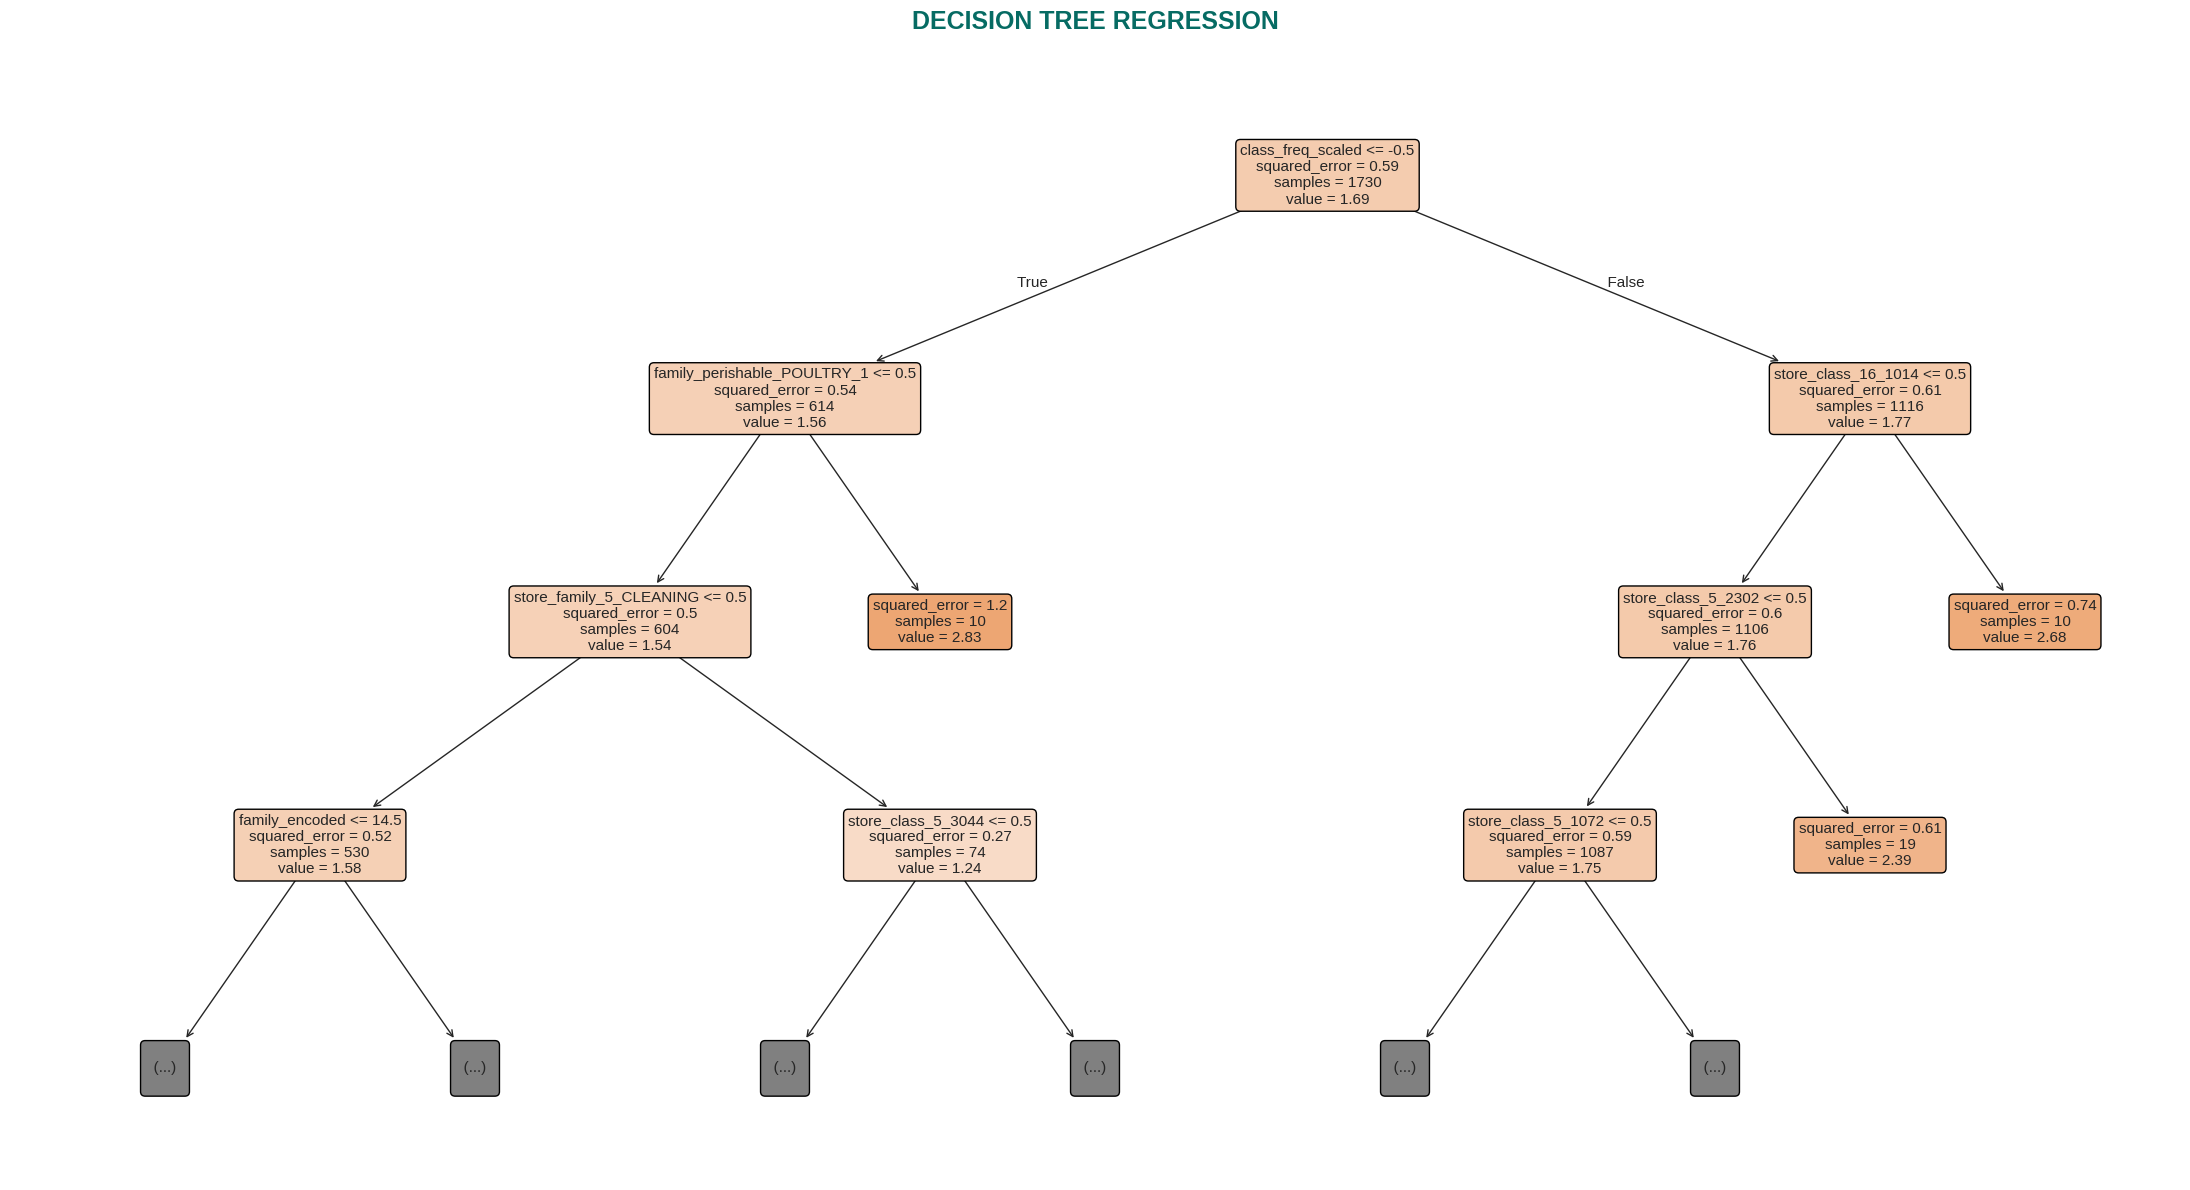

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor

if 'X_processed' in locals():
    feature_names = X_processed.columns.tolist()
else:
    feature_names = ['cluster', 'perishable', 'store_type_scaled', 'family_encoded', 'state_encoded',
                     'day_of_week', 'class_freq_scaled', 'family_freq_scaled', 'product_complexity_scaled']

if 'best_dt_model_info' in locals():
    max_depth_val = None if pd.isna(best_dt_model_info['Max_Depth']) else int(best_dt_model_info['Max_Depth'])
    min_samples_split_val = int(best_dt_model_info['Min_Samples_Split'])

    best_dt_model = DecisionTreeRegressor(
        max_depth=max_depth_val,
        min_samples_split=min_samples_split_val,
        random_state=42
    )

    best_dt_model.fit(X_processed, y)
else:
    print("Warning: best_dt_model_info not found. Cannot initialize the best Decision Tree model for visualization.")
    # Fallback if best_dt_model_info is not available
    best_dt_model = DecisionTreeRegressor(max_depth=3, random_state=42) # Default for visualization
    if 'X_processed' in locals() and 'y' in locals():
        best_dt_model.fit(X_processed, y)
    else:
        print("Error: X_processed or y not found. Cannot train fallback Decision Tree model.")


print("\n" + "=" * 100)
print("VISUALIZING DECISION TREE STRUCTURE")
print("=" * 100)

fig, ax = plt.subplots(figsize=(22, 12))


if 'best_dt_model' in locals() and best_dt_model is not None:
    plot_tree(best_dt_model,
              max_depth=3,
              feature_names=feature_names,
              ax=ax,
              fontsize=11,
              filled=True,
              rounded=True,
              precision=2)

    plt.title('DECISION TREE REGRESSION',
              fontsize=18, fontweight='bold', pad=25, color='#066b63')

    plt.tight_layout()
    plt.show()
else:
    print("Cannot visualize Decision Tree: Model not available.")